---
## 0. Install & Import Dependencies

In [3]:
!pip install datasets -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Etijah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re
import time
from collections import Counter
from datasets import load_dataset

# For reproducibility
np.random.seed(42)

C:\Users\Etijah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Load Dataset

In [5]:
print("Loading CoNLL-2003 dataset...")
dataset = load_dataset("lhoestq/conll2003", trust_remote_code=True)
all_sentences = []
for split in ["train", "validation", "test"]:
    for example in dataset[split]:
        all_sentences.append(example["tokens"]) 
print(f"Total sentences: {len(all_sentences)}")
print(f"Example sentence: {all_sentences[0][:10]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lhoestq/conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CoNLL-2003 dataset...


Total sentences: 20744
Example sentence: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


---
## 2. Preprocessing

In [ ]:
def preprocess_token(token):
    
    token = token.lower()
    # Keep only alphanumeric and hyphens; discard pure punctuation tokens
    token = re.sub(r"[^a-z0-9\-]", "", token)
    return token

corpus = []
for sentence in all_sentences:
    clean = [preprocess_token(t) for t in sentence]
    clean = [t for t in clean if len(t) > 0]   
    if clean:
        corpus.append(clean)

all_words = [w for sent in corpus for w in sent]
word_counts = Counter(all_words)

print(f"Corpus sentences : {len(corpus)}")
print(f"Total tokens     : {len(all_words)}")
print(f"Unique tokens    : {len(word_counts)}")

Corpus sentences : 20718
Total tokens     : 265446
Unique tokens    : 25907


In [ ]:
MIN_COUNT = 2       

vocab = {w for w, c in word_counts.items() if c >= MIN_COUNT}
vocab = sorted(vocab)                        
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)

print(f"Vocabulary size  : {VOCAB_SIZE}")


corpus = [[w for w in sent if w in word2idx] for sent in corpus]
corpus = [sent for sent in corpus if len(sent) > 1]   # need ≥2 words
print(f"Filtered corpus sentences: {len(corpus)}")

Vocabulary size  : 13836
Filtered corpus sentences: 20043


In [ ]:
# P(discard w) = 1 - sqrt(t / freq(w)),  t = 1e-4
T = 1e-4
total_tokens = sum(len(s) for s in corpus)
freq = {w: word_counts[w] / total_tokens for w in word2idx}

def subsample(sentence):
    keep = []
    for w in sentence:
        p_keep = np.sqrt(T / freq[w])
        if np.random.random() < p_keep:
            keep.append(w)
    return keep

corpus_sub = [subsample(sent) for sent in corpus]
corpus_sub = [sent for sent in corpus_sub if len(sent) > 1]
print(f"Post-subsampling sentences: {len(corpus_sub)}")

Post-subsampling sentences: 17817


---
## 3. Negative Sampling Distribution

Following the original paper: sample negatives proportional to $f(w)^{3/4}$.

In [ ]:
# Build the unigram^(3/4) table for negative sampling
counts_array = np.array([word_counts.get(idx2word[i], 0) for i in range(VOCAB_SIZE)],
                        dtype=np.float64)
counts_array = counts_array ** 0.75
neg_sample_probs = counts_array / counts_array.sum()

def sample_negatives(excluded_indices, k):
    negs = []
    excluded = set(excluded_indices)
    while len(negs) < k:
        sample = np.random.choice(VOCAB_SIZE, size=k * 2, p=neg_sample_probs)
        for s in sample:
            if s not in excluded:
                negs.append(s)
            if len(negs) == k:
                break
    return negs[:k]

---
## 4. Model – Skip-Gram with Negative Sampling (From Scratch)

### Architecture
Two embedding matrices:
- **W**  (center / input embeddings)  → shape `(V, D)`
- **W'** (context / output embeddings) → shape `(V, D)`

### Loss (per training pair)
$$\mathcal{L} = -\log \sigma(\mathbf{u}_o^\top \mathbf{v}_c)
  - \sum_{k=1}^{K} \log \sigma(-\mathbf{u}_k^\top \mathbf{v}_c)$$

### Manual Gradients
Let $s_o = \mathbf{u}_o^\top \mathbf{v}_c$ and $s_k = \mathbf{u}_k^\top \mathbf{v}_c$:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{v}_c}
  = (\sigma(s_o)-1)\,\mathbf{u}_o + \sum_k \sigma(s_k)\,\mathbf{u}_k$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{u}_o}
  = (\sigma(s_o)-1)\,\mathbf{v}_c$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{u}_k}
  = \sigma(s_k)\,\mathbf{v}_c$$

In [ ]:
class SkipGramNegativeSampling:
    def __init__(self, vocab_size, embed_dim, num_negatives=5, lr=0.025):
        self.V = vocab_size
        self.D = embed_dim
        self.K = num_negatives
        self.lr = lr 

        # Xavier-like initialisation
        scale = np.sqrt(1.0 / embed_dim)
        self.W  = np.random.uniform(-scale, scale, (vocab_size, embed_dim))  # center
        self.W_ = np.random.uniform(-scale, scale, (vocab_size, embed_dim))  # context

    @staticmethod
    def sigmoid(x):
        """Numerically stable sigmoid."""
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    def train_pair(self, target_idx, context_idx, neg_indices):
    
        v_c = self.W[target_idx]           # center embedding  (D,)
        u_o = self.W_[context_idx]         # positive context  (D,)
        U_k = self.W_[neg_indices]         # negative contexts (K, D)

        s_o  = np.dot(u_o, v_c)            
        s_k  = U_k @ v_c                  
        sig_o  = self.sigmoid(s_o)         # σ(s_o)
        sig_k  = self.sigmoid(s_k)         # σ(s_k)  (K,)

        loss = (-np.log(sig_o + 1e-10)
                - np.sum(np.log(1.0 - sig_k + 1e-10)))
        
        # ∂L/∂v_c
        grad_v_c = (sig_o - 1.0) * u_o + (sig_k[:, None] * U_k).sum(axis=0)

        # ∂L/∂u_o
        grad_u_o = (sig_o - 1.0) * v_c

        # ∂L/∂u_k  (K, D)
        grad_U_k = sig_k[:, None] * v_c[None, :]  # broadcast: (K,1)*(1,D)

        self.W[target_idx]   -= self.lr * grad_v_c
        self.W_[context_idx] -= self.lr * grad_u_o
        # scatter-add for (possibly repeated) negative indices
        np.add.at(self.W_, neg_indices, -self.lr * grad_U_k)

        return loss
    @property
    def embeddings(self):
        return (self.W + self.W_) / 2.0

---
## 5. Training

In [ ]:
EMBED_DIM    = 100
WINDOW_SIZE  = 2
NUM_NEGATIVES = 5
INIT_LR      = 0.025
MIN_LR       = 0.0001
EPOCHS       = 5

model = SkipGramNegativeSampling(
    vocab_size    = VOCAB_SIZE,
    embed_dim     = EMBED_DIM,
    num_negatives = NUM_NEGATIVES,
    lr            = INIT_LR,
)

print(f"Model ready | V={VOCAB_SIZE}, D={EMBED_DIM}, K={NUM_NEGATIVES}")
print(f"W  shape: {model.W.shape}")
print(f"W' shape: {model.W_.shape}")

Model ready | V=13836, D=100, K=5
W  shape: (13836, 100)
W' shape: (13836, 100)


In [ ]:
def generate_training_pairs(corpus, word2idx, window_size):
    pairs = []
    for sentence in corpus:
        indices = [word2idx[w] for w in sentence]
        n = len(indices)
        for i, target in enumerate(indices):
            # dynamic window size
            dyn_win = np.random.randint(1, window_size + 1)
            left  = max(0, i - dyn_win)
            right = min(n, i + dyn_win + 1)
            for j in range(left, right):
                if j != i:
                    pairs.append((target, indices[j]))
    return pairs

print("Pre-generating training pairs for epoch 1 preview...")
sample_pairs = generate_training_pairs(corpus_sub[:500], word2idx, WINDOW_SIZE)
print(f"Sample pairs from first 500 sentences: {len(sample_pairs)}")

Pre-generating training pairs for epoch 1 preview...
Sample pairs from first 500 sentences: 8694


In [ ]:
epoch_losses   = []    # average loss per epoch
step_losses    = []    # sampled step losses for plotting
LOG_EVERY      = 5000  # log every N pairs

total_start = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*60}")

    # Shuffle corpus each epoch
    np.random.shuffle(corpus_sub)

    # Generate (target, context) pairs
    pairs = generate_training_pairs(corpus_sub, word2idx, WINDOW_SIZE)
    np.random.shuffle(pairs)  # shuffle pairs too

    num_pairs    = len(pairs)
    epoch_loss   = 0.0
    t0           = time.time()

    for step, (target_idx, context_idx) in enumerate(pairs):

        progress = ((epoch - 1) * num_pairs + step) / (EPOCHS * num_pairs)
        model.lr = max(INIT_LR * (1.0 - progress), MIN_LR)
        neg_indices = sample_negatives([target_idx, context_idx], NUM_NEGATIVES)
        loss = model.train_pair(target_idx, context_idx, neg_indices)
        epoch_loss += loss

        if (step + 1) % LOG_EVERY == 0:
            avg_loss = epoch_loss / (step + 1)
            elapsed  = time.time() - t0
            pct      = 100.0 * (step + 1) / num_pairs
            print(f"  Step {step+1:>7d}/{num_pairs} ({pct:5.1f}%) "
                  f"| avg_loss={avg_loss:.4f} "
                  f"| lr={model.lr:.5f} "
                  f"| elapsed={elapsed:.1f}s")
            step_losses.append(avg_loss)

    avg_epoch_loss = epoch_loss / num_pairs
    epoch_losses.append(avg_epoch_loss)
    print(f"\n  ✓ Epoch {epoch} complete | avg_loss={avg_epoch_loss:.4f} "
          f"| time={time.time()-t0:.1f}s")

print(f"\nTotal training time: {time.time()-total_start:.1f}s")


Epoch 1/5
  Step    5000/314527 (  1.6%) | avg_loss=4.1600 | lr=0.02492 | elapsed=4.6s
  Step   10000/314527 (  3.2%) | avg_loss=4.1597 | lr=0.02484 | elapsed=10.9s
  Step   15000/314527 (  4.8%) | avg_loss=4.1598 | lr=0.02476 | elapsed=16.2s
  Step   20000/314527 (  6.4%) | avg_loss=4.1596 | lr=0.02468 | elapsed=21.9s
  Step   25000/314527 (  7.9%) | avg_loss=4.1594 | lr=0.02460 | elapsed=27.1s
  Step   30000/314527 (  9.5%) | avg_loss=4.1592 | lr=0.02452 | elapsed=32.6s
  Step   35000/314527 ( 11.1%) | avg_loss=4.1592 | lr=0.02444 | elapsed=37.3s
  Step   40000/314527 ( 12.7%) | avg_loss=4.1589 | lr=0.02436 | elapsed=40.5s
  Step   45000/314527 ( 14.3%) | avg_loss=4.1587 | lr=0.02428 | elapsed=43.4s
  Step   50000/314527 ( 15.9%) | avg_loss=4.1585 | lr=0.02421 | elapsed=46.2s
  Step   55000/314527 ( 17.5%) | avg_loss=4.1583 | lr=0.02413 | elapsed=49.1s
  Step   60000/314527 ( 19.1%) | avg_loss=4.1580 | lr=0.02405 | elapsed=52.2s
  Step   65000/314527 ( 20.7%) | avg_loss=4.1577 | lr=

### Training Loss Curve

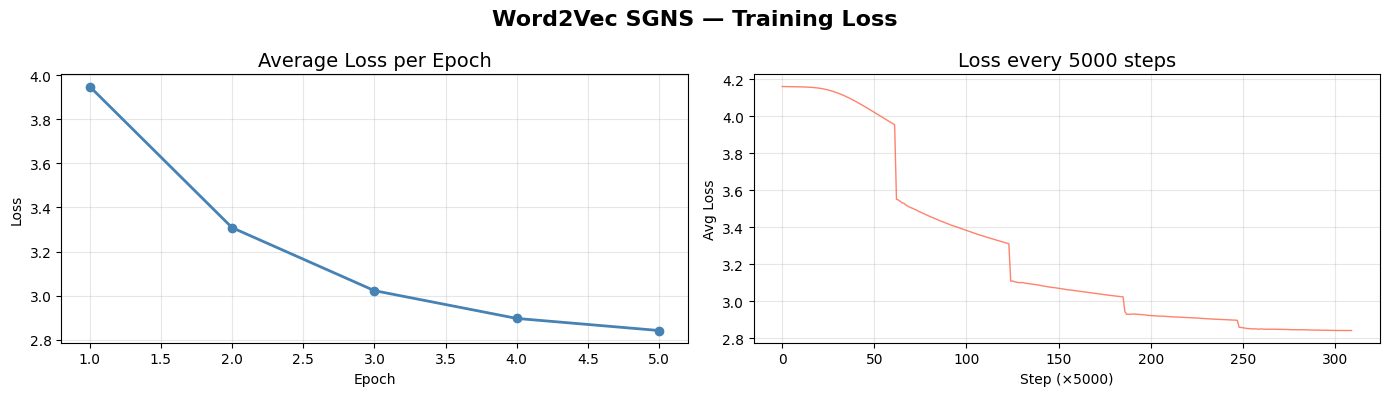

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, EPOCHS + 1), epoch_losses, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Average Loss per Epoch", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)


axes[1].plot(step_losses, color='tomato', linewidth=1, alpha=0.8)
axes[1].set_title(f"Loss every {LOG_EVERY} steps", fontsize=14)
axes[1].set_xlabel(f"Step (×{LOG_EVERY})")
axes[1].set_ylabel("Avg Loss")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Word2Vec SGNS — Training Loss", fontsize=16, fontweight='bold')
plt.tight_layout()

---
## 6. Save Embeddings

In [ ]:
embeddings = model.embeddings        
np.save("word_embeddings.npy", embeddings)

with open("vocab.pkl", "wb") as f:
    pickle.dump({
        "word2idx" : word2idx,
        "idx2word" : idx2word,
        "vocab"    : vocab,
    }, f)

print(f"Saved word_embeddings.npy  → shape {embeddings.shape}")
print(f"Saved vocab.pkl            → {len(word2idx)} words")

Saved word_embeddings.npy  → shape (13836, 100)
Saved vocab.pkl            → 13836 words


In [ ]:
loaded_emb = np.load("word_embeddings.npy")
with open("vocab.pkl", "rb") as f:
    loaded_vocab = pickle.load(f)

print("Load test passed ✓")
print(f"Embeddings shape : {loaded_emb.shape}")
print(f"Vocab size       : {len(loaded_vocab['word2idx'])}")

Load test passed ✓
Embeddings shape : (13836, 100)
Vocab size       : 13836


---
## 7. Word Analogy Function

Classic vector arithmetic:  
**A is to B as A\* is to B\***  
$$\hat{B}^* = \arg\max_{w \notin \{A,B,A^*\}}\ \cos\!\left(\mathbf{v}_w,\ \mathbf{v}_B - \mathbf{v}_A + \mathbf{v}_{A^*}\right)$$

In [ ]:
def cosine_similarity_matrix(query_vec, matrix):
    query_norm  = query_vec / (np.linalg.norm(query_vec) + 1e-10)
    norms       = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-10
    normed_mat  = matrix / norms
    return normed_mat @ query_norm


def most_similar(word, embeddings, word2idx, idx2word, topn=5):
    if word not in word2idx:
        return f"'{word}' not in vocabulary."
    idx   = word2idx[word]
    vec   = embeddings[idx]
    sims  = cosine_similarity_matrix(vec, embeddings)
    sims[idx] = -1   # exclude the query word itself
    top_idx = np.argsort(sims)[::-1][:topn]
    return [(idx2word[i], float(sims[i])) for i in top_idx]


def word_analogy(A, B, A_star, embeddings, word2idx, idx2word, topn=5):
    for w in [A, B, A_star]:
        if w not in word2idx:
            return f"'{w}' not in vocabulary."

    v_A      = embeddings[word2idx[A]]
    v_B      = embeddings[word2idx[B]]
    v_A_star = embeddings[word2idx[A_star]]

    # Query vector: B - A + A*
    query    = v_B - v_A + v_A_star

    sims     = cosine_similarity_matrix(query, embeddings)

    # Exclude the three input words from results
    for w in [A, B, A_star]:
        sims[word2idx[w]] = -1

    top_idx = np.argsort(sims)[::-1][:topn]
    results = [(idx2word[i], float(sims[i])) for i in top_idx]

    print(f"Analogy: '{A}' is to '{B}' as '{A_star}' is to ...")
    for rank, (word, score) in enumerate(results, 1):
        print(f"  #{rank}: {word:<20} (cos={score:.4f})")
    return results

print("Analogy function defined ✓")

Analogy function defined ✓


---
## 8. Qualitative Evaluation

In [ ]:
test_words = ["london", "germany", "president", "army", "tuesday"]

print("=" * 55)
print("Most Similar Words")
print("=" * 55)
for tw in test_words:
    results = most_similar(tw, embeddings, word2idx, idx2word, topn=5)
    if isinstance(results, str):
        print(f"  {tw}: {results}")
    else:
        nbrs = ', '.join(f"{w}({s:.3f})" for w, s in results)
        print(f"  {tw:12s} → {nbrs}")

Most Similar Words
  london       → 1996-08-31(0.802), 1996-08-30(0.786), 1996-08-28(0.777), 1996-08-22(0.767), 1996-12-06(0.763)
  germany      → 1996-08-28(0.548), women(0.536), bonn(0.535), scorers(0.529), halftime(0.525)
  president    → spokesman(0.578), s(0.524), to(0.497), israel(0.491), yasser(0.487)
  army         → albuquerque(0.366), get(0.343), might(0.341), intervention(0.337), granting(0.331)
  tuesday      → a(0.596), said(0.565), on(0.562), market(0.548), wednesday(0.541)


In [ ]:
print("=" * 55)
print("Word Analogy Examples")
print("=" * 55)

analogies = [
    ("paris", "france", "london"),         
    ("germany", "berlin", "france"),      
    ("monday", "tuesday", "january"),      
]

for A, B, A_star in analogies:
    print()
    word_analogy(A, B, A_star, embeddings, word2idx, idx2word, topn=3)

Word Analogy Examples

Analogy: 'paris' is to 'france' as 'london' is to ...
  #1: borac                (cos=0.4526)
  #2: berkrot              (cos=0.4470)
  #3: 460                  (cos=0.4113)

Analogy: 'germany' is to 'berlin' as 'france' is to ...
  #1: policies             (cos=0.4293)
  #2: poking               (cos=0.3637)
  #3: armed                (cos=0.3623)

Analogy: 'monday' is to 'tuesday' as 'january' is to ...
  #1: 55000-b              (cos=0.3571)
  #2: altered              (cos=0.3543)
  #3: csepel               (cos=0.3378)


---
## 9. Embedding Visualisation (t-SNE)

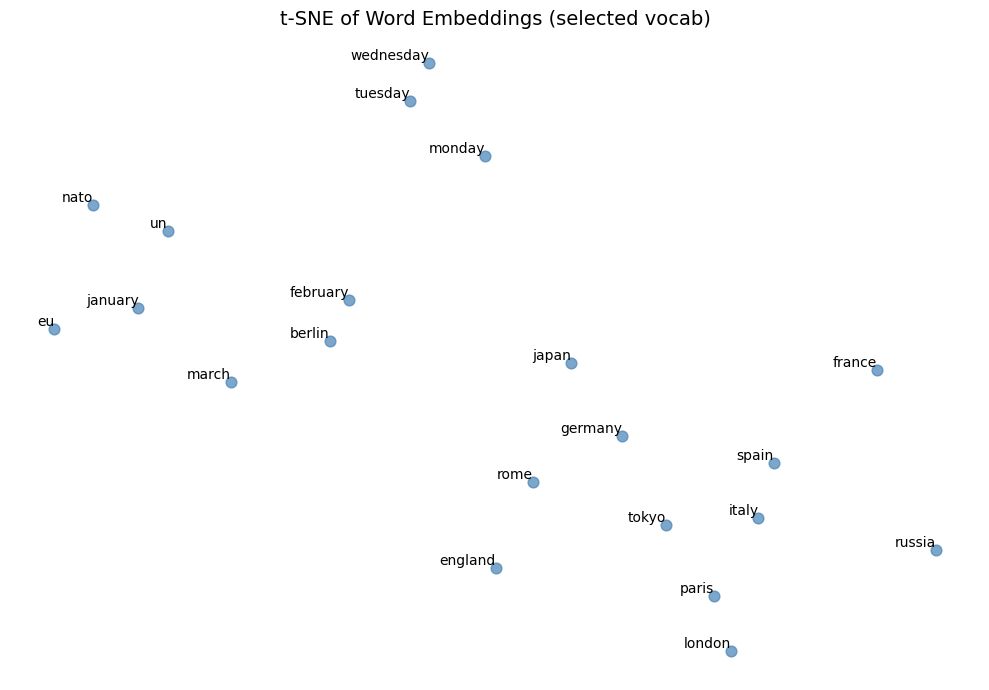

In [ ]:
from sklearn.manifold import TSNE

vis_words = [
    "france", "germany", "england", "spain", "italy", "russia", "japan",
    "london", "paris", "berlin", "tokyo", "rome",
    "un", "nato", "eu",
    "monday", "tuesday", "wednesday", "january", "february", "march",
]

vis_words = [w for w in vis_words if w in word2idx]
vis_vecs  = np.array([embeddings[word2idx[w]] for w in vis_words])

tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(vis_words)-1))
coords = tsne.fit_transform(vis_vecs)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=60, color='steelblue', alpha=0.7)
for i, word in enumerate(vis_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=10, ha='right', va='bottom')
plt.title("t-SNE of Word Embeddings (selected vocab)", fontsize=14)
plt.axis('off')
plt.tight_layout()